<a href="https://colab.research.google.com/github/Malki9/3601763_BD2/blob/main/3601763_BD2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.0 Business Understanding
### 1.1 Business Context

The data used in the analysis is coming from JcPenney which is an american department store chain which sells clothing and life style items at their phyiscal and online platforms. The dataset used in this project consists of the product informations, reviews, and demographic details of the customers. Understanding the customer reviews is essential which allows the company to get an idea about their products whether its successful in sales, identifying the quality of their products, how well they suits the customers, detect quality issues early, and tailor their marketing strategies based on customer preferences. This project is structured using the CRISP-DM approach and uses data analysis and natural language processing techniques to extract useful insights from the data.

### 1.2 Business Objectives

The study provided the following crucial business insights to support JCPenny's operations which they could answer their business queries.

01. Can JCPenny rely on the product ratings given by each customers. Is the customer rating consistent with the true sentiment given by the customers?
02. Can the customer ratings be predicted based on the review?
03. Which customers are demorgraphically active?
04. Which features of the product that the customers complement most and the features of the products which the customers complains the most?
05. Which product/ brand is mostly loved by the customer? and which product brand is mostly hated by the customers?
06. Does the product sales price has an effect on the customer rating given?





## 2.0 Data Understanding

The next step is to understand the data after the process of identifying the business objectives.

The main goal of this phase is to identify the data, which includes assessing the quality of the data, determining which data is more suitable for the analysis, and identifying the relationship among the datasets.

In here, the Data Understanding process is divided into a few steps as below:

1. Setup and Configurations
2. Load the Datasets
3. Identify the structure of the dataset
4. Data Integrity and Data Relationship Check
5. Checking Missing values

### 2.1 Setup and Configurations

First, we import the necessary libraries which is required in our analysis as initial process. The below is the libaries that we required in our analysis.

In [1]:
# Import the required libaries
import pandas as pd
import numpy as np
import json
import re
import plotly.express as px
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2.2 Load the Dataset

In order to begin the analysis, the datasets are loaded into the Python environment. This project uses 05 datasets, consisting of 03 CSV files and 02 JSON files. These datasets are imported as dataframes using the pandas library. To verify that the datasets have been loaded correctly and to obtain an initial understanding of their structure, the first four rows of each dataset are displayed.

In [2]:
# Create variables and load the .csv datasets
products = pd.read_csv('/content/products.csv')
reviews = pd.read_csv('/content/reviews.csv')
users = pd.read_csv('/content/users.csv')

# Load the Json files
jcpenney_reviewers = pd.read_json('/content/jcpenney_reviewers.json', lines = True)
jcpenney_products = pd.read_json('/content/jcpenney_products.json', lines = True)

In [3]:
jcpenney_reviewers.head(2)

,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]


In [4]:
jcpenney_products.head(2)

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."


In [5]:
jcpenney_products.head(2)

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."


In [6]:
jcpenney_reviewers.head(2)

,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]


In [7]:
reviews.head(2)

,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...


In [8]:
products.head(2)

,Uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000


In [9]:
users.head(2)

,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts


### 2.3 Identify the structure of the datasets

The '*info()*' function from the pandas library provides a summary of each dataset, including the number of rows and columns, column names, data types, and the number of non-null values in each column. Based on this summary, the following dataset structures are identified.

*   The users dataframe consists of 03 columns: Username, DOB, and State, which are object data types and consist of 5000 entries.

*   The products dataframe consists of 05 columns: Uniq_id, SKU, Name, Description, Price, and Av_Score. The Price and Av_Score are float data type and remaining columns are object datatypes and consists of 7982 entries, some columns illustrate the existence of null values.

*   The reviews dataframe consists of 04 columns: Uniq_id, Username, Score, and Review. The Score is of int datatype and remaining columns are object datatype and consists of 39063 entries and has no non-existence of null values.

*   The jcpenny_products dataframe consists of 15 columns: uniq_id, sku, name_title, description, list_price, sale_price, category, category_tree, average_product_rating, product_url, product_image_urls, brand, total_number_reviews, Reviews, Bought With. The columns average_product_ratings and total_number_reviews are of float and int datatypes, and the rest are object data type. This dataframe consists of 7982 entries and has no null values.

*   The jcpenny_reviews dataframe consists of 04 columns: Username, DOB, State, and Reviewed. All the columns are object datatype. This dataset consists of 5000 entries and has no null values.


Note: There are common columns_names included in each datasets. The next step involves in identifying the relationship in each of the dataframes.

In [10]:
# check the dataframes basic information
users.info()
products.info()
reviews.info()
jcpenney_products.info()
jcpenney_reviewers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  5000 non-null   object
 1   DOB       5000 non-null   object
 2   State     5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982 entries, 0 to 7981
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Uniq_id      7982 non-null   object 
 1   SKU          7915 non-null   object 
 2   Name         7982 non-null   object 
 3   Description  7439 non-null   object 
 4   Price        5816 non-null   float64
 5   Av_Score     7982 non-null   float64
dtypes: float64(2), object(4)
memory usage: 374.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39063 entries, 0 to 39062
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    -----

### 2.4 Data Intergrity and Data Relationship Check

The common columns/ identifiers in each dataset illustrates that datasets are relational. This involves checking the username in each datasets follows a particular standard format, checking all the usernames in users exist in both the reviews and jcpenney_reviewers, checking all the uniq_id in product dataset exists in reviews and jcpenney_products. Checking the quality of the data by identifying missing values, duplicates and identifying whether there's any inconsistency among the data.

In [11]:
# Check the Username column in the users, jcpenny_reviews and reviews dataset follows the same standard
# Define the pattern where the first 04 char are simple letters from a-z and the last for as int from 0-9
pattern = r'^[a-z]{4}[0-9]{4}$'
# Get the unique values in each of the dataset of username columns as a Dictionary
users_username = { 'users' : set(users['Username']), # convert the username column to set, eliminate the duplicates
                   'reviews': set(reviews['Username']),
                   'jcpenney_reviewers' : set(jcpenney_reviewers['Username'])
                   }

# Iterate through each value in the users_username
for key, value in users_username.items():
  invalid_found = False
  for username in value:
    if not re.fullmatch(pattern, username):
      print(f" Invalid username in {key}: {username}")
      invalid_found = True
  if not invalid_found: print(f" All usernames in {key} are in the particular standard")

 All usernames in users are in the particular standard
 All usernames in reviews are in the particular standard
 All usernames in jcpenney_reviewers are in the particular standard


In [12]:
# Check all the username in users are there in the jcpenny reviews
users['Username'].isin(jcpenney_reviewers['Username']).all()

np.True_

In [13]:
# Check the username is consistent with the state and dob
# Merge the two dataframes
comparison = users.merge(jcpenney_reviewers, on='Username', suffixes= ('_users', '_jcpenney_reviewers'))

mismatch = False

# Iterate through each row column
for index, rows in comparison.iterrows():
  DOB_match = rows['DOB_users'] == rows['DOB_jcpenney_reviewers']
  State_match = rows['State_users'] == rows['State_jcpenney_reviewers']

  if not (DOB_match and State_match): # Check if there is a mismatch
    print(f'The username {rows['Username']} has inconsistent DOB or State values')

if not mismatch:
  print(" All the username has the same DOB and State")
else:
  print(" There are some username with inconsistent DOB and State")

The username dqft3311 has inconsistent DOB or State values
The username dqft3311 has inconsistent DOB or State values
 All the username has the same DOB and State


In [14]:
# Check username in users and jcpenney_reviewers is unique
users['Username'].is_unique and jcpenney_reviewers['Username'].is_unique

False

In [15]:
# check for duplicate and print the duplicated rows in both users and jcpenny_reviewers dataset
users_duplicate = users[users.duplicated(subset=['Username'], keep=False)]
jcpenney_reviewers_duplicate = jcpenney_reviewers[jcpenney_reviewers.duplicated(subset=['Username'], keep=False)]
print(users_duplicate)
print(jcpenney_reviewers_duplicate)

      Username         DOB       State
731   dqft3311  28.07.1995   Tennessee
2619  dqft3311  03.08.1969  New Mexico
      Username         DOB       State                            Reviewed
731   dqft3311  28.07.1995   Tennessee  [5f280fb338485cfc30678998a42f0a55]
2619  dqft3311  03.08.1969  New Mexico  [571b86d307f94e9e8d7919b551c6bb52]


In [16]:
# Check all the username in jcpenny_reviews there in reviews
jcpenney_reviewers['Username'].isin(reviews['Username']).all()

np.False_

In [17]:
# Get the count of username not there in reviews
jcpenney_reviewers[~jcpenney_reviewers['Username'].isin(reviews['Username'])]['Username'].count()

np.int64(6)

In [18]:
# check the username which are not in the jcpenny_reviews have empty reviews
non_users= jcpenney_reviewers[~jcpenney_reviewers['Username'].isin(reviews['Username'])][['Username','Reviewed']]
non_users

,Username,Reviewed
373,qzsw4431,[]
1349,clar2422,[]
1562,eevm2113,[]
1869,jbym1321,[]
2257,eubf2214,[]
2410,djzq3441,[]


This concludes, the users dataset acts as the base dataset, as all usernames in users also appear in the jcpenney_reviewers and shares the same demographic features of DOB and State confirming data integrity. But, one username was found with multiple DOB and State values, indicating a duplicated record that will be removed during the data preparation stage. This confirms a one-to-one relationship between the users and jcpenney_reviewers datasets with a Reviewed column consisting of list of unique_ids reviewed by each usernames.

Additionally, six usernames from the users dataset do not appear in the reviews dataset. The review dataset contains the detailed review records the unique_id, username, score given to each product and the review which contains the review text. This dataset acts as the customer dataset of jcpenney which have reviews. So the six usernames in jcpenney_reviewers that doesn't match are not customers and they can be deleted as they do not contribute meaning information to the analysis. Thus, this confirms that there's a one-to-many relationship between the jcpenney_reviewers and reviews datasets, where one user can review multiple products.


In [19]:
# Check all the unique_id in product is there in jcpenney_products
products['Uniq_id'].isin(jcpenney_products['uniq_id']).all()

np.True_

In [20]:
# Check all uniq_id in jcpenney_products exist in reviews
jcpenney_products['uniq_id'].isin(reviews['Uniq_id']).all()

np.True_

In [21]:
# Check uniq_id is unique in product dataframe
products['Uniq_id'].is_unique

True

In [22]:
# Check sku is unique
products['SKU'].is_unique

False

Accordingly all the unique_id in product dataset exist in jcpenney_products dataframe and reviews dataset and one unique_id can have multiple sku. This illustrates that there's one to many relationship between the product and the review dataset. There's one to many relationship between the product and the jcpenney_products dataframes

### 2.5 Checking for missing values


The *".isnull()"* function is used to calculate the missing value in each column and summarised to seperate tables and then combined and aligned into a tabular format for easier comparison of missing values in each dataframe. Presenting the missing values in a tabular format helps to identify which columns has missing values which is essential in data preparation

In [23]:
# Check for null values in each dataframe as a count
# Display in a tabular format
# Function to create the dataframe consist of column and sum
def null_summary(dataset):
    return pd.DataFrame({
        "column": dataset.columns,
        "sum": dataset.isnull().sum().values
    })

# Create summaries of each dataframe
users_null = null_summary(users)
jc_reviews_null = null_summary(jcpenney_reviewers)
jc_products_null = null_summary(jcpenney_products)
products_null = null_summary(products)
reviews_null = null_summary(reviews)

# Put all in dictionary
tables = {
    "users": users_null,
    "jcpenney_reviews": jc_reviews_null,
    "reviews": reviews_null,
    "jc_products": jc_products_null,
    "products": products_null
}

# Find maximum number of rows
max_rows = max(len(dataset) for dataset in tables.values())

# Pad smaller tables
for name, dataset in tables.items():
    if len(dataset) < max_rows:
        padding = pd.DataFrame({
            "column": [""] * (max_rows - len(dataset)),
            "sum": [""] * (max_rows - len(dataset))
        })
        tables[name] = pd.concat([dataset, padding], ignore_index=True)

# Create final aligned table
final_table = pd.concat(tables, axis=1)

final_table

users     jcpenney_reviews       reviews                 jc_products  \
      column sum           column sum    column sum                  column   
0   Username   0         Username   0   Uniq_id   0                 uniq_id   
1        DOB   0              DOB   0  Username   0                     sku   
2      State   0            State   0     Score   0              name_title   
3                        Reviewed   0    Review   0             description   
4                                                                list_price   
5                                                                sale_price   
6                                                                  category   
7                                                             category_tree   
8                                                    average_product_rating   
9                                                               product_url   
10                                                       product_image_urls   
11                                                                    brand   
12                                                     total_number_reviews   
13                                                                  Reviews   
14                                                              Bought With   

           products        
   sum       column   sum  
0    0      Uniq_id     0  
1    0          SKU    67  
2    0         Name     0  
3    0  Description   543  
4    0        Price  2166  
5    0     Av_Score     0  
6    0                     
7    0                     
8    0                     
9    0                     
10   0                     
11   0                     
12   0                     
13   0                     
14   0

Based on the above output, there are 67 null values in SKU, 543 null values in Description, 2166 null values in Price columns in the product dataframe. The other dataframes do not consists of null values.

## 3.0 Data Preparation

After understanding the data. The next step involves in preparing the Data for the analysis and Modelling.
The Data Preparation process is divided into the below steps:

##### 3.1 Standardizing the column names
##### 3.2 Changing the datatype
##### 3.3 Handling missing values and Data Duplicates.
##### 3.4 Preprocessing the unstructured data (Review text)


### 3.1 Standardizing the column names

Standardizing is done in two ways, renamed the column names with spaces and converted all column names to simple. This will eliminate errors caused by spaces and case sensitivity when accessing the column names during data cleaning and merging.

In [24]:
# Create a dictionary of the dataset
datasets = {
    'users': users,
    'jcpenney_products': jcpenney_products,
    'jcpenney_reviewers': jcpenney_reviewers,
    'products': products,
    'reviews': reviews
}

In [25]:
# Replace the column name 'Bought With' with to bought_with
jcpenney_products.rename(columns={'Bought With': 'bought_with'}, inplace=True)
# Replace the column names with simple
for dataset_name, dataset in datasets.items():
  for column in dataset.columns:
    dataset.rename(columns={column: column.lower()}, inplace=True)

### 3.2 Changing the datatypes

The column names "sale_price" and "list_price" and "dob" appeared to be of object data type which is unrealistic and thus conversion of these datatypes to numeric and date_time is essential before modelling. By converting to the apropriate datatype. These columns will now have null values.

In [61]:
# Change the datatype of the list_price and the sale_price in the product_review
jcpenney_products['sale_price'] = pd.to_numeric(jcpenney_products['sale_price'], errors='coerce')
jcpenney_products['list_price'] = pd.to_numeric(jcpenney_products['list_price'], errors='coerce')
jcpenney_reviewers['dob'] = pd.to_datetime(jcpenney_reviewers['dob'])


/tmp/ipykernel_109778/1649228568.py:4: UserWarning:

Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



### 3.3 Handling missing values and duplicates

During data understanding stage, the missing values were identified using the .isnull() function. But the .isnull() function will only identify standard missing values like NaN or None. In some columns associated with object data type will have missing values in other forms. The object data type columns can have strings, list, dictionaries of which the missing values may appear as empty strings with '' or space ' ', empty list[], empty dictionaries {}. These are not recognised by the .isnull() function.
Inorder, to address this scenario an additional preprocessing step was taken, first the datatype of the object was detected and empty strings were stripped and replaced with pd.Na and also empty lists and dictionaries were also replaced with pd.Na. Additionally the missing values of numeric columns including the sales_price and list_price which was treated as a object datatype also being replaced with pd.Na. This ensures that all the missing values are being considered as NaN which will make them to correctly identified and handled appropriately.

In [27]:
# Check the actual datatype of columns: reviewed, reviews, bought_with
print(jcpenney_reviewers['reviewed'].apply(type).value_counts(), jcpenney_products['reviews'].apply(type).value_counts(), jcpenney_products['bought_with'].apply(type).value_counts())

reviewed
<class 'list'>    5000
Name: count, dtype: int64 reviews
<class 'list'>    7982
Name: count, dtype: int64 bought_with
<class 'list'>    7982
Name: count, dtype: int64


In [62]:
# Iterate through each column in each dataset and check the datatype
for dataset_name, dataset in datasets.items():
  for column in dataset.columns:
    # Get the columns of the type object
    if dataset[column].dtype == 'object':
      non_null = None
      for value in dataset[column]:
        if value is not None:
          non_null = value
          break

      # Replace the null value with NaN of string column
      if isinstance(non_null, str):
        dataset[column] = (dataset[column].str.strip().replace('', pd.NA))

      # Replace the null value with Nan of list column
      elif isinstance(non_null, list):
        dataset[column] = dataset[column].apply(lambda x: pd.NA if isinstance(x, list) and len(x) == 0 else x)

        # Replace the null values with Nan of Dictionary column
      elif isinstance(non_null, dict):
        dataset[column] = dataset[column].apply(lambda x: pd.NA if isinstance(x, dict) and len(x) == 0 else x)

    # Replace the null values with Nan of the integer and float datatype
    elif dataset[column].dtype in ['int64', 'float64']:
            dataset[column] = dataset[column].replace('', pd.NA)


Now lets, rerun the code which displays the missing values in tabular format and call the final_table

In [63]:
# Call the final_table
final_table

users     jcpenney_reviews       reviews                 jc_products  \
      column sum           column sum    column sum                  column   
0   Username   0         Username   0   Uniq_id   0                 uniq_id   
1        DOB   0              DOB   0  Username   0                     sku   
2      State   0            State   0     Score   0              name_title   
3                        Reviewed   0    Review   0             description   
4                                                                list_price   
5                                                                sale_price   
6                                                                  category   
7                                                             category_tree   
8                                                    average_product_rating   
9                                                               product_url   
10                                                       product_image_urls   
11                                                                    brand   
12                                                     total_number_reviews   
13                                                                  Reviews   
14                                                              Bought With   

           products        
   sum       column   sum  
0    0      Uniq_id     0  
1    0          SKU    67  
2    0         Name     0  
3    0  Description   543  
4    0        Price  2166  
5    0     Av_Score     0  
6    0                     
7    0                     
8    0                     
9    0                     
10   0                     
11   0                     
12   0                     
13   0                     
14   0

Accordingly, there are 971 null values in reviewed column, the null value count in sku, description, list_price is same in jcpenny_products and products dataframe and there are 16 null values in sales_price, category and category_tree has 636 null values and 157 null values in product_url columns. These null values should be treated appropiately as these columns are essential in modelling. First lets start by treating the null values in reviewed column.

During the data understanding phase there were 06 usernames that does not exist in review columns and those usernames have nit reviewed any products. Dropping those usernames will reduce the null count in reviewed column.
After removing these records, the remaining null values in the reviewed column were filled by mapping the username in the jcpenney_reviewers dataset with the corresponding username values in the reviews dataset. This was done by grouping the reviews dataset by username and collecting the list of uniq_id values reviewed by each username. The resulting mapping was then used to populate the Reviewed column, ensuring that each user is associated with the correct list of uniq_id they have reviewed.

In [30]:
# Fill the null values in reviewed column
# Drop the rows in jcpenny_reviews where the non existence usernames of review dataset which are not in the jcpenny_reviews
jcpenney_reviewers = jcpenney_reviewers.drop(non_users.index)

# Map the username with username
username_mapping = reviews.groupby('username')['uniq_id'].apply(list)
# Fill the null values in the Reviewed column
jcpenney_reviewers['reviewed'] = jcpenney_reviewers['username'].map(username_mapping) # This fillout the missing unique_id that the users have reviewed including the null

The one to one relationship identified in products, and jcpenney_products dataframe can be used to replace the null values in sku. Firstly, the uniq_id's of null sku are taken. These unique_id's are then checked with the products dataframe as all the unique_id's are in jcpenney_prodcucts dataframe and then check whether they are also consist with null values. Since the sku is an important feature we remove the null sku which exist in both dataframe. This confirms that the products with valid identifiers are considered to our analysis.

In [31]:
# Get the uniq_id of null sku
uniq_id = jcpenney_products.loc[jcpenney_products['sku'].isnull(), 'uniq_id']
# Check uniq_id in products dataset
match_id = products.loc[(products['uniq_id'].isin(uniq_id) & (products['sku'].isnull()))]
if match_id is not None:
  # Drop the rows in both dataset
  jcpenney_products = jcpenney_products.drop(match_id.index)
  products = products.drop(match_id.index)

Missing values in the description, list_price, and sale_price columns of the jcpenney_products dataset and the corresponding columns in the products dataset were first filled within each dataset by grouping records based on sku and product name, and applying forward and backward fill to propagate existing values. For records that still contained missing values, the uniq_id was used to retrieve matching non-null values from the products dataset and fill the missing entries in jcpenney_products. Any rows that continued to contain missing values after these steps were removed from both datasets to ensure that only records with complete and consistent product information were retained.

In [32]:
# Fill the null rows in description, list_price and sales_price columns with the sku, name_title combination
columns_fill = [('description','description'), ('list_price', 'price'), ('sale_price','av_score')]
for jcpenny_column, products_column in columns_fill:
  # Fill nulls in jcpenney_products and products by propagating non-null values within groups
  jcpenney_products[jcpenny_column] = jcpenney_products.groupby(['sku', 'name_title'])[jcpenny_column].transform(lambda x: x.ffill().bfill())
  products[products_column] = products.groupby(['sku', 'name'])[products_column].transform(lambda x: x.ffill().bfill())

  # Find the rows in Jcpenny data which are still null
  null_jcpenny = jcpenney_products[jcpenney_products[jcpenny_column].isnull()]

  # Iterate through each row to fill from the 'products' dataframe if possible
  for uid, row in null_jcpenny.iterrows():
    id = row['uniq_id']

    # Find matching values in the 'products' dataframe for the current 'uniq_id'
    match_values = products.loc[(products['uniq_id'] == id) & (products[products_column].notnull()), products_column]

    # If a matching non-null value is found, replace the null in 'jcpenney_products'
    if not match_values.empty:
        # Use .item() for safer scalar extraction from a single-element Series
        jcpenney_products.at[uid, jcpenny_column] = match_values.iloc[0].item()

  # After attempting to fill for the current column, identify and drop rows that still have nulls
  # Get 'uniq_id's that are still null in jcpenney_products for the current jcpenny_column
  still_null_jcpenney_ids = jcpenney_products.loc[jcpenney_products[jcpenny_column].isnull(), 'uniq_id'].unique()

  # Get 'uniq_id's that are still null in products for the current products_column
  still_null_products_ids = products.loc[products[products_column].isnull(), 'uniq_id'].unique()

  # Combine unique ids from both dataframes that still have nulls in the respective columns
  ids_to_drop_combined = pd.unique(list(still_null_jcpenney_ids) + list(still_null_products_ids))

  # Drop these identified rows from both dataframes based on 'uniq_id'
  jcpenney_products = jcpenney_products[~jcpenney_products['uniq_id'].isin(ids_to_drop_combined)]
  products = products[~products['uniq_id'].isin(ids_to_drop_combined)]

/tmp/ipykernel_109778/2259092200.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  products[products_column] = products.groupby(['sku', 'name'])[products_column].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_109778/2259092200.py:31: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  ids_to_drop_combined = pd.unique(list(still_null_jcpenney_ids) + list(still_null_products_ids))
/tmp/ipykernel_109778/2259092200.py:31: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  ids_to_drop_combined = pd.unique(list(still_null_jcpenney_ids) + list(still_null_products_ids))
/tm

By grouping the records with sku, the null values in category and category_tree column was filled by propagating the values with forward and backward filling. The remaining null in sku and product_image_urls were dropped.

In [33]:
# Fill the null_values in the category, category_tree columns propagating non-null values within groups
jcpenney_products[['category','category_tree']] = jcpenney_products.groupby('sku')[['category','category_tree']].transform(lambda x: x.ffill().bfill())

# Drop the rows where the category column is still null and null values in product_image_urls
jcpenney_products = jcpenney_products.dropna(subset=['category', 'product_image_urls'])


After treating the null values its essential to remove the duplicated rows which are identified in the data understanding the phase. The username had two instances which the second instance will be removed by keeping the first instance.

In [34]:
# Drop the second instance in the of the duplicated username from both the dataset
users = users.drop_duplicates(subset='username', keep='first')
jcpenney_reviewers = jcpenney_reviewers.drop_duplicates(subset='username', keep='first')

Note: The backward and forward filling are techniques used to replace missing values by getting the nearby non-value of the grouping.The forward filling will replace the null value with the previous non-null value of the group while the backward filling will replace the null value with the next non-null value of the group. By applying both will remove all the null values which are either before or after the group.

### 3.4 Preprocessing the text in Review column

The only unstructured textual data found is the customer reviews and it requires preprocessing before it is used for the sentiment analysis or ML models. Therefore a multiple NLP techniques were applied with the Natural Language Toolkit (NTLK) libary to clean and standardize the textual data.
The first step includes downloading the necessary resources from NLTK, includes WordNet, stopwords, VADER lexicon and punkt tokenizer.

*   punkt_tab: Supports tokenization/ split the sentence to word
*   stopwords: Supports removal of stop words such as "the", "is" ,"and","of" which appear frquently in text, contributes litle to the semantic meaning and eliminating these words will help focus on informative terms in the review text during the semantimental analysis. There are 198 stop word defined in this package.
*   WordNet : Support lemmatization. Lemmatization is considered to be important in a sentimental analysis where we need to understand the text. Lemmatization converts the words into the correct dictionary form which consider the meaning and the grammer of the context. While in stemming removes prefixes and suffixes from the word. For example if we consider the below sentence from the review after stop word removal.
"never worry fit alfred dunner clothing sizes true size fits perfectly great value money"
1.   Lemmatized sentence: "never worry fit alfred dunner clothing size true size fit perfectly great value money". fits --> fit, sizes ---> sizes, which are real worlds

2.   Stemming sentence: "never worri fit alfr dunner cloth size true size fit perfectli great valu money". worry --> worri
perfectly --> perfectli, which does not have a real meaning or word.

As a result, lemmatization produces cleaner and more interpretable text representations, making it more suitable for analysing customer reviews.

A preprocessing function was defined to clean each review includes the following steps:

1.   Converting each and every word in the sentence to lowercase
2.   Include only letters, remove punctuations, numbers.
3.   Tokenize the sentence - split the sentence to words/tokens
4.   Remove stop words
5.   Lemmatization

In [35]:
# Download the NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [36]:
# Get the stopwords from nltk.corpus
stop_words = set(stopwords.words('english'))

# Get the lemmatizer function
lemmatizer = WordNetLemmatizer()

# Print the no.of stopswords defined in the package
print(f"There are {len(stop_words)} stop words defined in the package")

# Define a function to convert the raw review to sting of words
def review_to_words(raw_review):
  # Convert to lower case
  raw_review = raw_review.lower()

  # Remove punctuation and non_letters which are numbers and any other characters
  letters_only = re.sub("[^a-zA-Z]", " ", raw_review)

  # Tokenize
  words = nltk.word_tokenize(letters_only)

  # Remove stop words and apply lemmatization for each word
  meaningful_words = []
  for word in words:
    if word not in stop_words:
      meaningful_words.append(lemmatizer.lemmatize(word))

  # Return the list of cleaned reviewed
  return(" ".join(meaningful_words))

# Apply the funtion to each review
reviews['clean_review'] = reviews['review'].apply(review_to_words)


There are 198 stop words defined in the package


Now that we have cleaned text reviews. There are rows which can have empty reviews or white spaces. Therefore it is essential identify those as NaN and remove those rows.


In [37]:
# Replace '' or ' ' in clean_review column with NaN
reviews['clean_review'] = reviews['clean_review'].replace('', pd.NA)

# Count the null values in clean_review
reviews['clean_review'].isnull().sum()

np.int64(17)

Now we can see that the clean_review column has 17 null values. Hence we drop those rows

In [38]:
# Drop the null valuse in the column reviews
reviews = reviews.dropna(subset=['clean_review'])

##4.0 Modelling

### 4.1 Sentiment Analysis using VADER

After completing the data preparation next steps involves performing sentiment analysis on the cleaned review text. Sentiment analysis helps to identify the underlying opinion or emotional tone expressed in customer reviews irrespective of the score given, This involoves determining a review conveys a positive, neutral, or negative sentiment.

In this study the rule-based sentiment analysis approach was applied using the VADER (Valence Aware Dictionary and Sentiment Reasoner) model from the NLTK library. VADER uses a predefined sentiment lexicon and linguistic rules to assign sentiment scores to words and phrases in a sentence. It is useful in scenarios for analysing short texts like social media posts or customer reviews.

In the below code, a SentimentIntensityAnalyzer object was first created. The polarity_scores() function was applied to the clean_review column, which contains the preprocessed review text. This function calculates four sentiment metrics for each review:

*   Negative score (neg) : Its the proportion of negative words in the text.
*   Neutral score (neu) : proportion of neutral words.
*   Positive score (pos): proportion of positive words.
*   Compound score (compound): overall sentiment.

The compound score represents the overall sentiment of the review and is a normalized value ranging between -1 and 1, where values closer to -1 indicate negative sentiment, values near 0 indicate neutral sentiment, and values closer to 1 indicate positive sentiment.

The compound score is calculated using the following normalization formula:

$$
compound = \frac{x}{{\sqrt{x^2+15}}}
$$

where:

*x* is the sum of the sentiment scores of individual words in the review

15 is a normalization constant used by the VADER model

Finally, the generated sentiment scores were converted into a dataframe and merged with the original reviews dataset, allowing the sentiment scores to be used for further analysis and modelling.

In [39]:
# Create SentimentIntensityAnalyzer object
sid = SentimentIntensityAnalyzer()

# Get the Vader score to a dictionary for each review
vader_score = reviews['clean_review'].apply(lambda x: sid.polarity_scores(x))

# Convert the vader_score to a dataframe
vader_score = pd.DataFrame(vader_score.tolist())

# Rename the columns
vader_score = vader_score.rename(columns={'neg': 'negative_score', 'neu': 'neutral_score', 'pos': 'positive_score', 'compound': 'compound_score'})

# Join the vader_score to the original dataframe
reviews = pd.concat([reviews.reset_index(drop=True), vader_score.reset_index(drop=True)], axis=1)


In [40]:
reviews.head(2)

,uniq_id,username,score,review,clean_review,negative_score,neutral_score,positive_score,compound_score
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...,never worry fit alfred dunner clothing size tr...,0.156,0.258,0.586,0.9133
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...,good quality fabric perfect fit washed well iron,0.000,0.263,0.737,0.8807


After getting the vader_score its essential to classify each review to sentiment categories which is either negative, neutral or positive. The overall sentiment range is -1 to 1 and the classification is done based on Vader guideline [vader-sentiment-analysis](https://hex.tech/templates/sentiment-analysis/vader-sentiment-analysis/) where the classification is conducted below:
*   compound_score <= -0.05: negative
*   compound_score >= 0.05: positive
*   compound_score between -0.05 to 0.05: neutral






In [41]:
# Assign the sentiment_class to vader_score/ compound_score
def vader_to_rating(compound_score):
    if compound_score <= -0.05:
        return 'negative'
    elif compound_score >= 0.05:
        return 'positive'
    else:
        return 'neutral'

# Apply the function
reviews['vader_sentiment'] = reviews['compound_score'].apply(vader_to_rating)

Next step invovles to create the actual sentiment using the score where the score range from 0 - 5.
If we classify those score. It will be as below:
*   0-2 --> Negative
*   3 --> Neutral
*   4-5 --> Positive








In [42]:
# Assign the true sentiment labels
reviews['true_sentiment'] = reviews['score'].apply(lambda x: 'neutral' if x == 3 else ('negative' if x <= 2 else "positive"))

In [43]:
reviews.describe()

,score,negative_score,neutral_score,positive_score,compound_score
count,39046.000000,39046.000000,39046.000000,39046.000000,39046.000000
mean,1.487758,0.037346,0.540887,0.421741,0.693177
std,1.400379,0.072898,0.190776,0.207854,0.343909
min,0.000000,0.000000,0.000000,0.000000,-0.969000
25%,0.000000,0.000000,0.408000,0.277000,0.624900
50%,1.000000,0.000000,0.544000,0.419000,0.827100
75%,2.000000,0.055000,0.667000,0.572000,0.916900
max,5.000000,1.000000,1.000000,1.000000,0.998200


Accordingly we can see than the ratings given for each product falls under 0-2 ratings. This indicates that the dataset is highly imbalanced. Therefore the model will learn from its majority and will give the predicted ratings/ score within 0-2.

According to the descriptive statistics we can see that there are discrepancy between the numeric score given and the sentiment score expressed within the review text. The mean score is approximately 1.49 which indicates low ratings. But the mean of the sentiment score obtained from the Vader sentiment analyzer is 0.69, which indicates that the textual context of the review is largerly positive. The median sentiment_score of 0.82 illustrates that irespective of the low numeric rating given more than half of the reviews given are strong positive sentiment. This suggests that there are inconsitency with the datasets, this inconsitency is known as label noises which the assigned rating does not accurately reflect the sentiment depicted by the review text. This can be further proved by the confusion Matrix.

Confusion Matrix through heatmap

In [44]:
# confusion matrix
confusion_matrix = pd.crosstab(reviews['true_sentiment'], reviews['vader_sentiment'])
confusion_matrix

vader_sentiment,negative,neutral,positive
true_sentiment,,,
negative,1421,1131,28344
neutral,157,126,3721
positive,283,249,3614


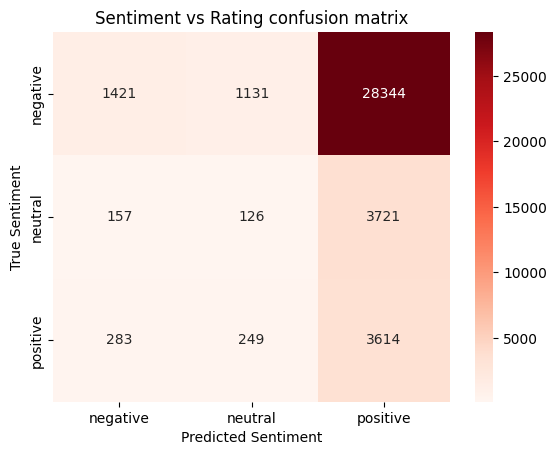

In [45]:
# Visualize the confusion matrix
# Heatmap to visualize the consfusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Reds')

plt.title("Sentiment vs Rating confusion matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.show()


Calculating the mismatch rate

In [46]:
# Get a column named mismatch label
reviews['mismatch_label'] = (reviews['true_sentiment'] == reviews['vader_sentiment'])

# Calculate the mismatch_rate
mismatch_rate = (reviews['mismatch_label'] == False).sum() / len(reviews) * 100
mismatch_rate

np.float64(86.782256825283)

Accuracy Score

In [47]:
# Import accuracy score from sklearn
from sklearn.metrics import accuracy_score

# Calculate the accuracy score
accuracy = accuracy_score(reviews['true_sentiment'], reviews['vader_sentiment'])
print("Accuracy_Score",accuracy)

Accuracy_Score 0.13217743174717


Accordingly we can say that there's a significant mismatch portion between the numerical rating given by each customer and the textual score. This illustrates the misinterpretation of the customer rating scales. In some records the text sentiments says positive but the rating score given is 1 or 2 which illustrates a label noise existences in the dataset. Thus the model score for the sentiment analysis will be lower. Now let's predict the true sentiment of the from the review text, without consdering the score given.


### 4.2 Predicting true sentiment from the review text with ML models

In [48]:
# Define x and y
x = reviews['clean_review']
y = reviews['true_sentiment']

In [49]:
# TF-DF Vectorization
tfid = TfidfVectorizer(max_features=15000, ngram_range=(1,3), stop_words='english')
X_tfid = tfid.fit_transform(x)

In [50]:
# Train/Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tfid, y, test_size=0.2, stratify = y, random_state=42)

In [51]:
#from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
model = LogisticRegression( max_iter=3000, class_weight='balanced', multi_class='multinomial')

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [52]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.4909090909090909


### 4.4 Brand most liked and disliked

/tmp/ipykernel_109778/1859664234.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_brands['percentage'] = (top_brands['positive_review_count'] / total_positive) * 100
/tmp/ipykernel_109778/1859664234.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


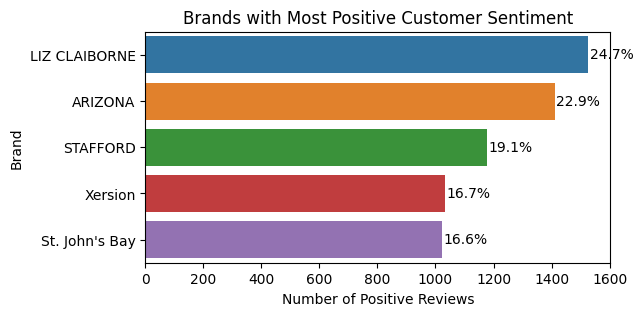

In [53]:
# Merge reviews with product brand
reviews_products = reviews.merge(
    jcpenney_products[['uniq_id', 'brand']],
    on='uniq_id',
    how='left'
)

# Count positive sentiment per brand
positive_category = (
    reviews_products[reviews_products['vader_sentiment'] == 'positive']
    .groupby('brand')
    .size()
    .reset_index(name='positive_review_count')
    .sort_values(by='positive_review_count', ascending=False)
)

# Select top 10 brands
top_brands = positive_category.head(5)

# Calculate percentages
total_positive = top_brands['positive_review_count'].sum()
top_brands['percentage'] = (top_brands['positive_review_count'] / total_positive) * 100

# Plot
plt.figure(figsize=(6,3))

ax = sns.barplot(
    data=top_brands,
    x='positive_review_count',
    y='brand',
    palette='tab10'
)

# Add percentage labels
for i, row in top_brands.iterrows():
    ax.text(
        row['positive_review_count'] + 5,
        list(top_brands.index).index(i),
        f"{row['percentage']:.1f}%",
        va='center'
    )

plt.title("Brands with Most Positive Customer Sentiment")
plt.xlabel("Number of Positive Reviews")
plt.ylabel("Brand")

plt.show()

/tmp/ipykernel_109778/1167736808.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_brands['percentage'] = (top_brands['negative_review_count'] / total_negative) * 100
/tmp/ipykernel_109778/1167736808.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


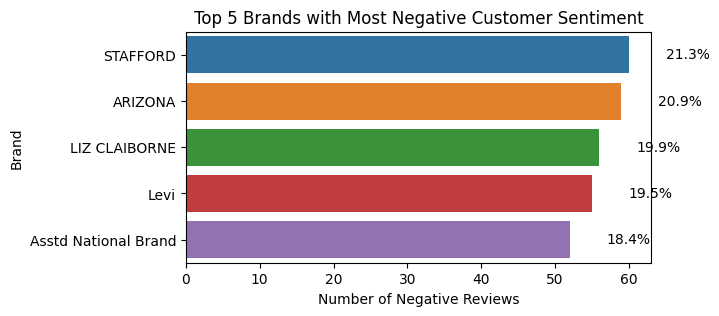

In [54]:
# Merge reviews with product brand
reviews_products = reviews.merge(
    jcpenney_products[['uniq_id', 'brand']],
    on='uniq_id',
    how='left'
)

# Count negative sentiment per brand
negative_category = (
    reviews_products[reviews_products['vader_sentiment'] == 'negative']
    .groupby('brand')
    .size()
    .reset_index(name='negative_review_count')
    .sort_values(by='negative_review_count', ascending=False)
)

# Select top 5 brands
top_brands = negative_category.head(5)

# Calculate percentages
total_negative = top_brands['negative_review_count'].sum()
top_brands['percentage'] = (top_brands['negative_review_count'] / total_negative) * 100

# Plot
plt.figure(figsize=(6,3))

ax = sns.barplot(
    data=top_brands,
    x='negative_review_count',
    y='brand',
    palette='tab10'
)

# Add percentage labels
for i, row in top_brands.iterrows():
    ax.text(
        row['negative_review_count'] + 5,
        list(top_brands.index).index(i),
        f"{row['percentage']:.1f}%",
        va='center'
    )

plt.title("Top 5 Brands with Most Negative Customer Sentiment")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("Brand")

plt.show()

### 4.3 Topic Modelling/ Identifying common themes in the top brands

To identify the common themes in the reviews given by customers topic modelling is done. Topic modelling falls under unsupervised machine learning. To identify the common themes
For Ml models to identify the unstructured data the text are being converted to numeric format using CounterVectorizer which converts text to document term matrix which represent the frequency of each word in each review.
Then the Latent Drihlet Allocation(LDA) algorithm is applied to identify the common themes. The LDA algorithm groups words that appears together frequently as topics in the review. Then assign probabilities for each topic in the review and rank them.

In [55]:
top_brands = ['LIZ CLAIBORNE', 'ARIZONA']

positive_reviews = reviews_products[
    (reviews_products['brand'].isin(top_brands)) &
    (reviews_products['vader_sentiment'] == 'positive')
]

vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.9,
    min_df=10
)

dtm = vectorizer.fit_transform(positive_reviews['clean_review'])


lda = LatentDirichletAllocation(
    n_components=4,
    random_state=42
)

lda.fit(dtm)

words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}:")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 1:
['fit', 'really', 'love', 'look', 'foot', 'like', 'size', 'comfortable', 'wear', 'shoe']

Topic 2:
['store', 'pair', 'pant', 'time', 'long', 'great', 'short', 'size', 'jean', 'fit']

Topic 3:
['quality', 'comfortable', 'color', 'size', 'look', 'good', 'great', 'pant', 'love', 'fit']

Topic 4:
['boot', 'buy', 'bought', 'soft', 'comfortable', 'price', 'shirt', 'color', 'love', 'great']


Thus, the following themes can be derived:


*   Fit and comfort
*   Sizing and Clothing fit
*   Quality and Appearance
*   Price and Material Comfort





/tmp/ipykernel_109778/806309928.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


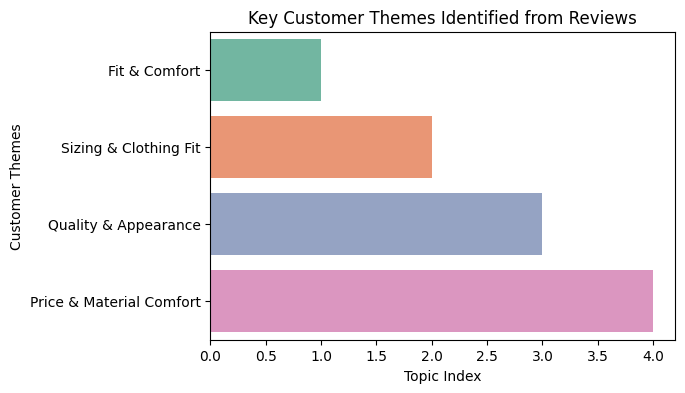

In [56]:
topics = {
    "Fit & Comfort": 1,
    "Sizing & Clothing Fit": 2,
    "Quality & Appearance": 3,
    "Price & Material Comfort": 4
}

topic_df = pd.DataFrame({
    "Topic": list(topics.keys()),
    "Topic_Number": list(topics.values())
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=topic_df,
    x="Topic_Number",
    y="Topic",
    palette="Set2"
)

plt.title("Key Customer Themes Identified from Reviews")
plt.xlabel("Topic Index")
plt.ylabel("Customer Themes")

plt.show()

In [57]:
# top disliked brand
top_disliked_brands = ['STAFFORD', 'ARIZONA']

negative_reviews = reviews_products[
    (reviews_products['brand'].isin(top_disliked_brands)) &
    (reviews_products['vader_sentiment'] == 'negative')
]

vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.9,
    min_df=10
)

dtm = vectorizer.fit_transform(negative_reviews['clean_review'])


lda = LatentDirichletAllocation(
    n_components=4,
    random_state=42
)

lda.fit(dtm)

words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}:")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 1:
['problem', 'disappointed', 'husband', 'bought', 'ordered', 'color', 'fit', 'pair', 'size', 'waist']

Topic 2:
['bought', 'disappointed', 'im', 'wear', 'time', 'stafford', 'theyre', 'size', 'shirt', 'quality']

Topic 3:
['waist', 'color', 'size', 'return', 'husband', 'way', 'bought', 'disappointed', 'right', 'pant']

Topic 4:
['shirt', 'wear', 'disappointed', 'return', 'way', 'husband', 'big', 'problem', 'time', 'shoe']


Thus, the following themes can be derived:
*   sizing and waist fit problem
*   shirt size and quality problems
*   Problems in product durability
*   Product return due to size issues.



/tmp/ipykernel_109778/1342932765.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


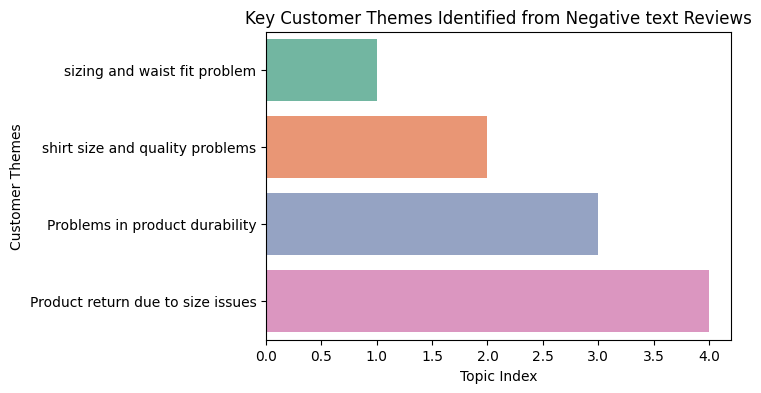

In [58]:
topics = {
    "sizing and waist fit problem": 1,
    "shirt size and quality problems": 2,
    "Problems in product durability": 3,
    "Product return due to size issues": 4
}

topic_df = pd.DataFrame({
    "Topic": list(topics.keys()),
    "Topic_Number": list(topics.values())
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=topic_df,
    x="Topic_Number",
    y="Topic",
    palette="Set2"
)

plt.title("Key Customer Themes Identified from Negative text Reviews")
plt.xlabel("Topic Index")
plt.ylabel("Customer Themes")

plt.show()

### 4.4 Geographic Distribution of Consumer

In [59]:
# Distribution of consumers across state using map visualization
state_mapping = {
"Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
"Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
"Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
"Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
"Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO",
"Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ",
"New Mexico":"NM","New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH",
"Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
"South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
"Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

jcpenney_reviewers['state'] = jcpenney_reviewers['state'].map(state_mapping)

state_counts = (jcpenney_reviewers.groupby('state').size().reset_index(name='consumer_count'))

fig = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='consumer_count',
    scope='usa',
    color_continuous_scale='Blues',
    labels={'consumer_count':'Number of Consumers'}
)

# Add numbers on states
fig.add_trace(go.Scattergeo(
    locations=state_counts['state'],
    locationmode='USA-states',
    text=state_counts['consumer_count'],
    mode='text',
    textfont=dict(size=9, color="black")
))

fig.update_layout(
    title="Geographical Distribution of JC Penney Consumers"
)

fig.show()

## 5.0 Evaluation and Deployment